In [19]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

url = 'https://www.coingecko.com/'
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
soup = BeautifulSoup(response.text, 'html.parser')

table = soup.find('table')
headers = [th.get_text(strip=True) for th in table.find('tr').find_all('th')]

rows = []
for tr in table.find_all('tr')[1:]:
    cols = tr.find_all('td')
    if not cols:
        continue

    # indexes 4,5,6 correspond to Price Change 1h, 24h, 7d & 30d columns (based on site layout)
    percent_cols = [4, 5, 6, 7]  

    row_data = []
    for idx, td in enumerate(cols):
        text_value = td.get_text(strip=True)
        if idx in percent_cols:
            span_tag = td.find('span')
            sign = ''
            if span_tag:
                classes = span_tag.get('class', [])
                if any( 'gecko-up' in c for c in classes):
                    sign = '+'
                elif any( 'gecko-down' in c for c in classes):
                    sign = '-'
            row_data.append(sign + text_value)
        else:
            row_data.append(text_value)

    rows.append(row_data) 

df = pd.DataFrame(rows, columns=headers)
df.head()

,,#,Coin,,Price,1h,24h,7d,30d,24h Volume,Market Cap,FDV,Market Cap / FDV,Last 7 Days
0,,1,BitcoinBTC,Buy,"$118,902",+0.2%,-2.6%,+4.0%,1.0%,"$50,387,727,519","$2,364,165,598,168","$2,364,165,598,168",1.0,
1,,2,EthereumETH,Buy,"$4,292.09",-0.1%,-0.3%,+16.9%,45.4%,"$39,289,100,703","$517,368,877,937","$517,368,877,937",1.0,
2,,3,XRPXRP,Buy,$3.14,-0.1%,-3.9%,+3.2%,13.2%,"$8,916,913,392","$185,798,280,320","$313,230,656,417",0.59,
3,,4,TetherUSDT,Buy,$0.9999,+0.0%,+0.0%,+0.0%,0.0%,"$98,276,163,187","$164,609,517,982","$164,609,517,982",1.0,
4,,5,BNBBNB,Buy,$807.35,+0.0%,-1.4%,+6.1%,17.3%,"$1,724,929,235","$112,283,438,381","$112,283,438,381",1.0,


In [20]:
df=df.drop(columns=['','#','Last 7 Days'], errors='ignore')
for col in df.columns:
    if df[col].astype(str).str.contains(r'[\$%]').any():
        df[col] = (
            df[col].astype(str)
                    .str.replace(r'%', '', regex=True)
                    .str.replace(r',','',regex=True)
                    .str.replace(r'\$', '', regex=True)
        )
        # Convert to float
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,Coin,Price,1h,24h,7d,30d,24h Volume,Market Cap,FDV,Market Cap / FDV
0,BitcoinBTC,118902.0000,0.2,-2.6,4.0,1.0,5.038773e+10,2364165598168,2364165598168,1.0
1,EthereumETH,4292.0900,-0.1,-0.3,16.9,45.4,3.928910e+10,517368877937,517368877937,1.0
2,XRPXRP,3.1400,-0.1,-3.9,3.2,13.2,8.916913e+09,185798280320,313230656417,0.59
3,TetherUSDT,0.9999,0.0,0.0,0.0,0.0,9.827616e+10,164609517982,164609517982,1.0
4,BNBBNB,807.3500,0.0,-1.4,6.1,17.3,1.724929e+09,112283438381,112283438381,1.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Coin              100 non-null    object 
 1   Price             100 non-null    float64
 2   1h                100 non-null    float64
 3   24h               100 non-null    float64
 4   7d                100 non-null    float64
 5   30d               100 non-null    float64
 6   24h Volume        100 non-null    float64
 7   Market Cap        100 non-null    int64  
 8   FDV               100 non-null    int64  
 9   Market Cap / FDV  100 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 7.9+ KB


In [22]:
df.describe()

,Price,1h,24h,7d,30d,24h Volume,Market Cap,FDV
count,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5382.315660,-0.051000,-3.635000,6.216000,16.711000,2.523246e+09,4.029543e+10,4.536875e+10
std,23335.813645,0.772964,3.537515,9.563332,22.531235,1.165056e+10,2.418278e+11,2.431267e+11
min,0.000011,-5.700000,-17.200000,-14.000000,0.000000,0.000000e+00,1.273885e+09,1.276259e+09
25%,0.791750,-0.200000,-6.200000,0.100000,1.700000,4.182833e+07,1.764622e+09,2.103645e+09
50%,3.270000,0.000000,-3.350000,3.950000,8.050000,1.400752e+08,2.815689e+09,4.759404e+09
75%,133.400000,0.100000,-0.200000,8.650000,22.875000,5.041158e+08,8.813379e+09,1.180185e+10
max,119038.000000,4.200000,2.600000,60.300000,144.300000,9.827616e+10,2.364166e+12,2.364166e+12


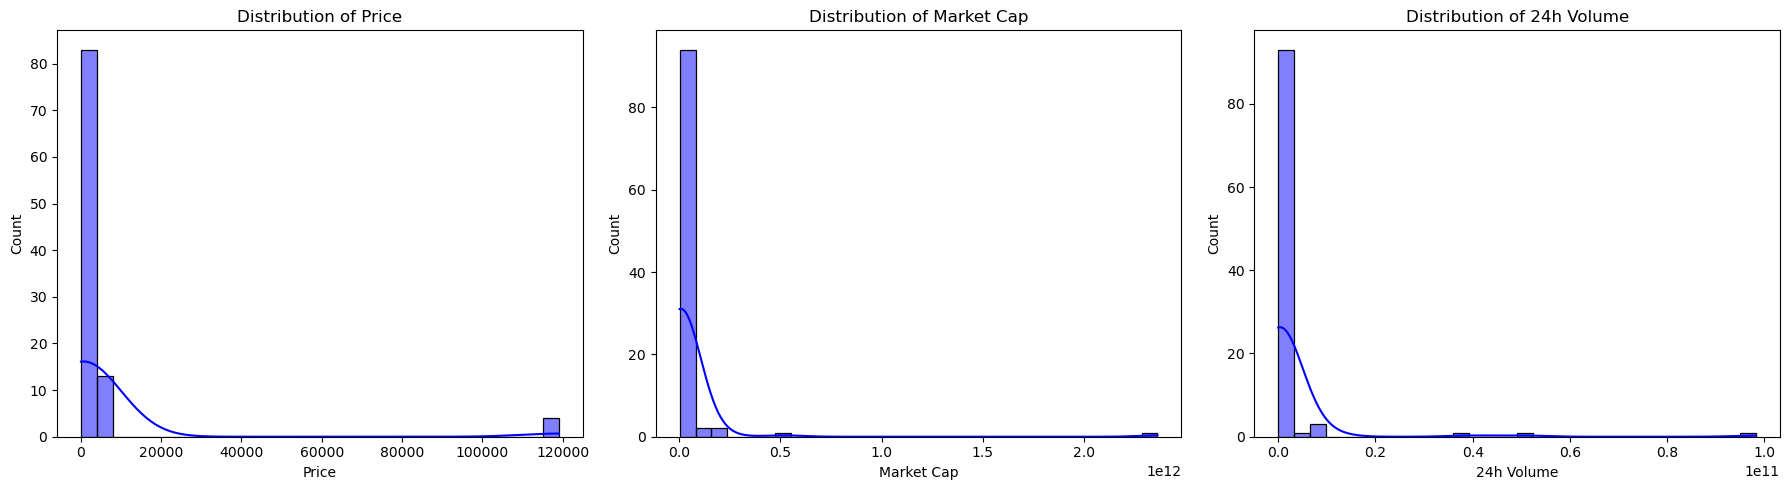

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['Price', 'Market Cap', '24h Volume']
plt.figure(figsize=(18, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

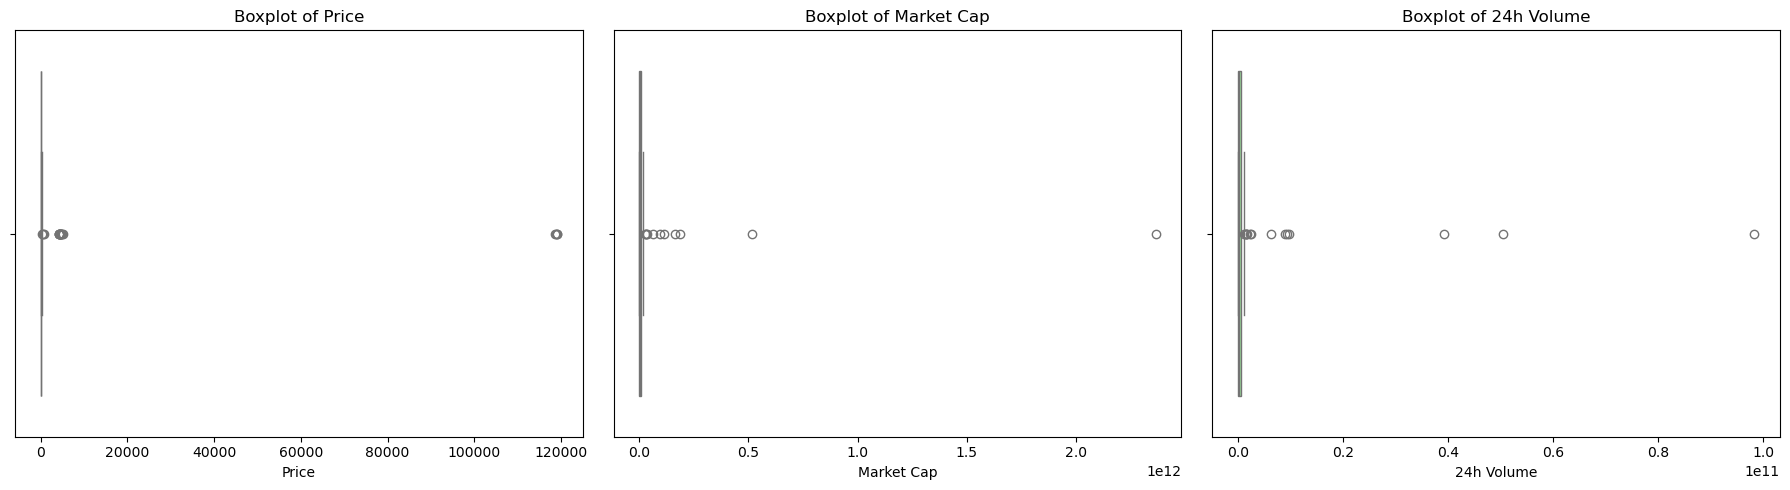

In [30]:
plt.figure(figsize=(18, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col].dropna(), color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

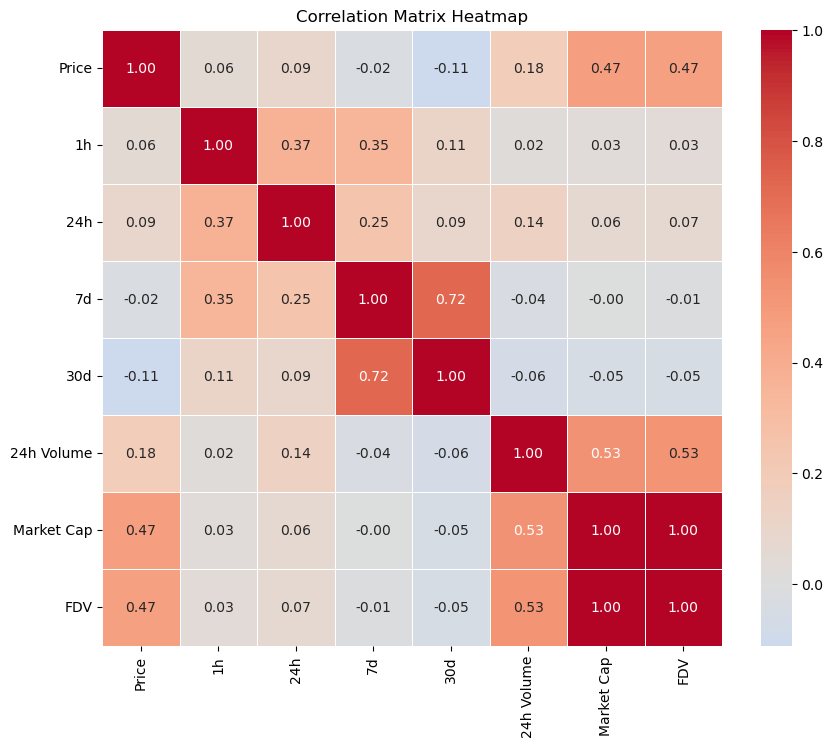

In [31]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # show correlation coefficients on heatmap
    cmap='coolwarm',    
    center=0,            
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [32]:
strong_corrs = (
    corr_matrix.where(lambda x: (x.abs() > 0.4) & (x.abs() < 0.99))
    .stack()
    .reset_index()
    .rename(columns={0: 'correlation'})
    .sort_values(by='correlation', ascending=False)
)

print("Strong correlations (> 0.4 or < -0.4):")
strong_corrs

Strong correlations (> 0.4 or < -0.4):


,level_0,level_1,correlation
3,30d,7d,0.721237
2,7d,30d,0.721237
4,24h Volume,Market Cap,0.533638
7,Market Cap,24h Volume,0.533638
5,24h Volume,FDV,0.531144
9,FDV,24h Volume,0.531144
6,Market Cap,Price,0.474292
0,Price,Market Cap,0.474292
1,Price,FDV,0.466908
8,FDV,Price,0.466908


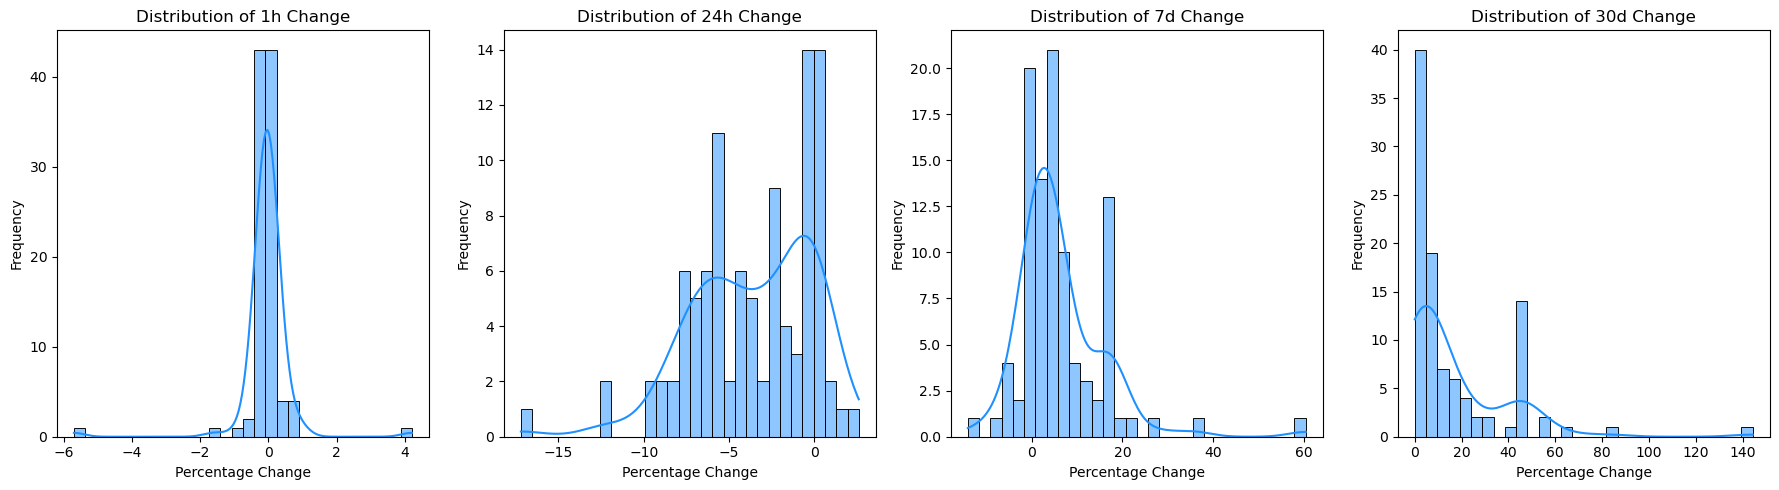

In [33]:
percent_cols = ['1h', '24h', '7d', '30d']
plt.figure(figsize=(18, 5))
for i, col in enumerate(percent_cols, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='dodgerblue')
    plt.title(f'Distribution of {col} Change')
    plt.xlabel('Percentage Change')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show() 

In [34]:
for col in percent_cols:
    counts = {
        "positive": int((df[col] > 0).sum()),
        "negative": int((df[col] < 0).sum()),
        "zero": int((df[col] == 0).sum())
    }
    print(f"{col} change counts:")
    print(counts)

1h change counts:
{'positive': 33, 'negative': 48, 'zero': 19}
24h change counts:
{'positive': 5, 'negative': 82, 'zero': 13}
7d change counts:
{'positive': 77, 'negative': 13, 'zero': 10}
30d change counts:
{'positive': 90, 'negative': 0, 'zero': 10}


In [35]:
print("Top cryptocurrencies by Market Cap:")
print(df[['Coin', 'Market Cap']].sort_values(by='Market Cap', ascending=False).head(10))

Top cryptocurrencies by Market Cap:
                     Coin     Market Cap
0              BitcoinBTC  2364165598168
1             EthereumETH   517368877937
2                  XRPXRP   185798280320
3              TetherUSDT   164609517982
4                  BNBBNB   112283438381
5               SolanaSOL    94237479342
6                USDCUSDC    65546939501
7  Lido Staked EtherSTETH    38005750922
8            DogecoinDOGE    33573285662
9                 TRONTRX    32819156079


In [36]:
print("\nTop cryptocurrencies by Price:")
print(df[['Coin', 'Price']].sort_values(by='Price', ascending=False).head(10))


Top cryptocurrencies by Price:
                         Coin      Price
32  Coinbase Wrapped BTCCBBTC  119038.00
79     Lombard Staked BTCLBTC  118958.00
0                  BitcoinBTC  118902.00
12        Wrapped BitcoinWBTC  118650.00
11        Wrapped stETHWSTETH    5187.82
62        Rocket Pool ETHRETH    4873.66
83     Liquid Staked ETHLSETH    4657.92
15    Wrapped Beacon ETHWBETH    4612.85
18          Wrapped eETHWEETH    4596.26
84    Mantle Staked EtherMETH    4570.88


In [37]:
print("\nTop cryptocurrencies by Volume of last 24 h:")
print(df[['Coin', '24h Volume']].sort_values(by='24h Volume', ascending=False).head(10))


Top cryptocurrencies by Volume of last 24 h:
                                             Coin    24h Volume
3                                      TetherUSDT  9.827616e+10
0                                      BitcoinBTC  5.038773e+10
1                                     EthereumETH  3.928910e+10
95                         First Digital USDFDUSD  9.782533e+09
6                                        USDCUSDC  9.369652e+09
2                                          XRPXRP  8.916913e+09
5                                       SolanaSOL  6.266492e+09
8                                    DogecoinDOGE  2.431770e+09
29  Binance Bridged USDT (BNB Smart Chain)BSC-USD  2.286804e+09
4                                          BNBBNB  1.724929e+09


# Key Insights
1. Bitcoin Dominance: In the market cap ranking plot, Bitcoin stands far ahead of other coins, occupying the top spot with a market cap that’s significantly larger than the rest — the bar for BTC clearly dwarfs Ethereum’s and other altcoins’ bars.

2. Volume Distribution: The trading volume distribution plot shows that a few large‑cap coins (like BTC and ETH and USDT) drive most of the total traded volume, while the vast majority of coins have relatively small daily volumes.

3. Performance Spread: The 24h, 7d and 30d percentage change histograms reveal a mixed market for today but a overall positive i.e. increase — with many coins clustered close to 0% change but a small number of outliers both on the positive and negative side, indicating pockets of high volatility for today but for longer range there's a clear dominance on the positive side showing a net increase in cypto market.